<h1>Разведочный анализ данных. Исследование и визуализация данных.</h1>

<h2>1) Текстовое описание набора данных</h2>
<p>Для выполнения будем использовать этот датасет с данными о результатах студентов:
https://www.kaggle.com/datasets/amar5693/student-performance-dataset.

Этот датасет может использоваться для анализа привычек, успеваемости, психологического здоровья студентов. Знания, полученные с его помощью, могут указать на слабые места учебной программы и помочь преподавателям найти подход к студентам для успешной сдачи экзаменов.

Датасет состоит из одного файла: 
ultimate_student_productivity_dataset_5000.csv

Он содержит следующие колонки:
<ul>
    <li>Student_id - идентификатор студента</li>
    <li>Age - возраст студента в годах</li>
    <li>Genger - пол студента</li>
    <li>Academic_level - тип получаемого образования</li>
    <li>Study_hours - время обучения в часах</li>
    <li>Self_study_hours - время домашнего обучения в часах</li>
    <li>Online_classes_hours - время онлайн обучения в часах</li>
    <li>Social_media_hours - время, проведённое в соцсетях, в часах</li>
    <li>Gaming_hours - время, потраченное на игры, в часах</li>
    <li>Sleep_hours - время сна в часах</li>
    <li>Screen_time_hours - время перед экраном в часах</li>
    <li>Exercise_minutes - время, потраченное на занятия физическими упражнениями, в минутах</li>
    <li>Caffeine_intake_mg - потребляемый кофеин в миллиграммах</li>
    <li>Part_time_job - флаг наличия подработки</li>
    <li>Upcoming_deadline - флаг наличия приближающегося дедлайна</li>
    <li>Internet_quality - уровень качества интернет соединения</li>
    <li>Mental_health_score - коэффициент оценки уровня психологического здоровья студента в баллах</li>
    <li>Focus_index - индекс оценки сфокусированности студента в баллах</li>
    <li>Burnout_level - индекс оценки степени выгорания студента в баллах</li>
    <li>Productivity_score - индекс оценки продуктивности студента в баллах</li>
    <li>Exam_score - целевой признак. Баллы, которые студент получил за экзамен</li>
</ul></p>

<h3>Импорт библиотек</h3>
<p>Импортируем библиотеки с помощью команды import. Как правило, все команды import размещают в первой ячейке ноутбука, но мы в этом примере будем подключать все библиотеки последовательно, по мере их использования.</p>

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

/home/tal3nt3d/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


<h3>Загрузка данных</h3>
<p>Загрузим файлы датасета в помощью библиотеки Pandas.</p>

In [5]:
data = pd.read_csv('ultimate_student_productivity_dataset_5000.csv', sep=",")

<h2>2) Основные характеристики датасета</h2>

In [6]:
#Выведем первые 5 строк датасета
data.head(5)

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


In [7]:
#Выведем размеры датасета
data.shape

(5000, 21)

In [8]:
#Выведем список колонок с типами данных
data.dtypes

student_id                int64
age                       int64
gender                   object
academic_level           object
study_hours             float64
self_study_hours        float64
online_classes_hours    float64
social_media_hours      float64
gaming_hours            float64
sleep_hours             float64
screen_time_hours       float64
exercise_minutes          int64
caffeine_intake_mg        int64
part_time_job             int64
upcoming_deadline         int64
internet_quality         object
mental_health_score       int64
focus_index             float64
burnout_level           float64
productivity_score      float64
exam_score              float64
dtype: object

In [15]:
#Проверим датасет на наличие пустых ячеек
for col in data.columns:
    temp = data[data[col].isnull()].shape[0]
    print('{} - {}'.format(col, temp))

student_id - 0
age - 0
gender - 0
academic_level - 0
study_hours - 0
self_study_hours - 0
online_classes_hours - 0
social_media_hours - 0
gaming_hours - 0
sleep_hours - 0
screen_time_hours - 0
exercise_minutes - 0
caffeine_intake_mg - 0
part_time_job - 0
upcoming_deadline - 0
internet_quality - 0
mental_health_score - 0
focus_index - 0
burnout_level - 0
productivity_score - 0
exam_score - 0


In [17]:
data.describe()

,student_id,age,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,20.520400,4.539594,2.478734,2.011984,2.998086,1.564514,7.016492,6.979588,74.535600,251.450400,0.498200,0.501400,5.507400,29.431616,45.615324,37.267716,18.803752
std,1443.520003,2.870406,1.821665,1.177990,0.983906,1.467949,1.110807,1.163692,2.486214,42.932293,143.842712,0.500047,0.500048,2.869145,9.962902,14.246591,16.849397,12.130840
min,1.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1250.750000,18.000000,3.250000,1.660000,1.320000,1.990000,0.670000,6.237500,5.280000,37.000000,129.000000,0.000000,0.000000,3.000000,22.567500,35.727500,25.290000,9.337500
50%,2500.500000,20.000000,4.530000,2.480000,2.010000,2.980000,1.490000,7.010000,6.950000,75.000000,252.000000,0.000000,1.000000,5.000000,29.430000,45.690000,36.860000,18.010000
75%,3750.250000,23.000000,5.760000,3.290000,2.690000,4.030000,2.340000,7.810000,8.710000,112.000000,376.000000,1.000000,1.000000,8.000000,36.242500,55.352500,49.142500,27.400000
max,5000.000000,25.000000,11.840000,7.410000,6.000000,8.280000,5.640000,10.000000,15.300000,149.000000,499.000000,1.000000,1.000000,10.000000,63.480000,97.580000,98.020000,64.090000


<p>Целевой признак является вещественным числом и принадлежит отрезку [1, 64.09]</p>

<h2>3) Визуальное исследование датасета</h2>

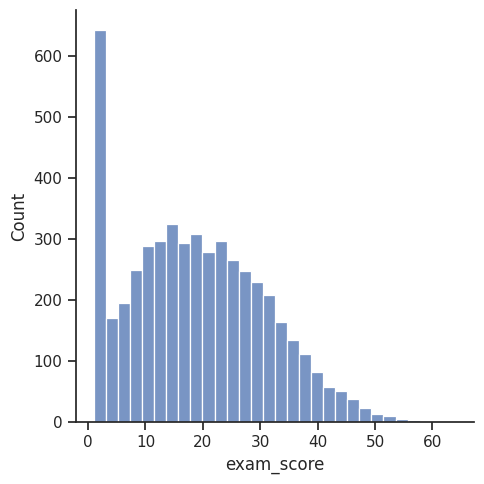

In [27]:
#Построим гистограмму распределения целевого признака
sns.displot(data['exam_score'])

<p>Мы видим нормальное распределение и резкое преобладание минимальнных баллов. Скорее всего, это связано с тем, что датасет синтетический и данные не совсем отражают действительность.</p>

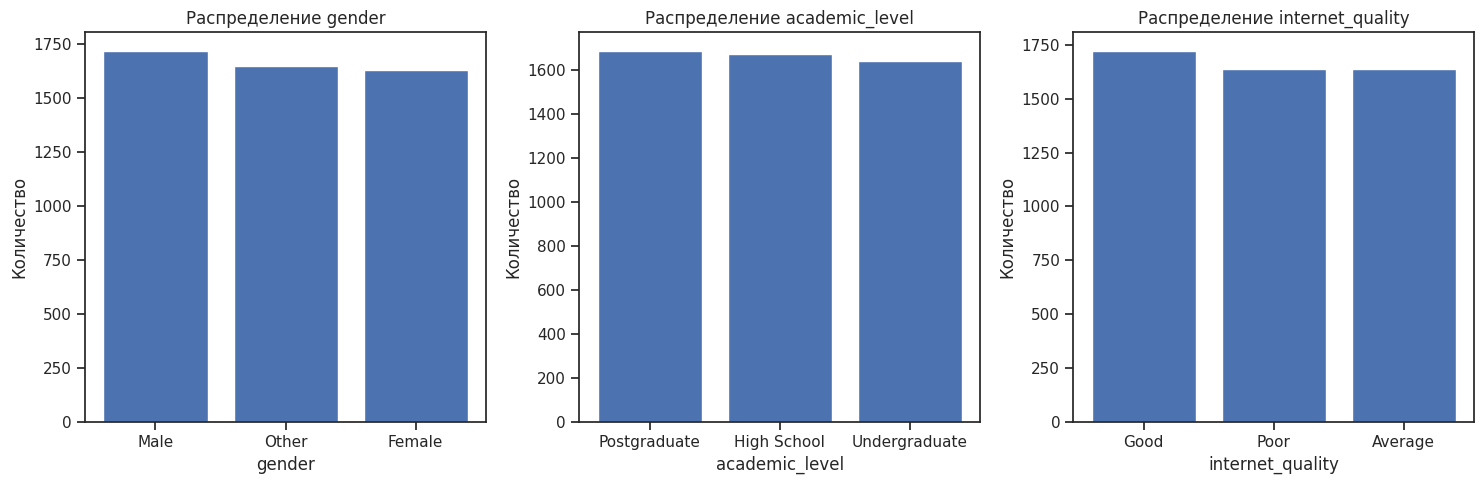

In [33]:
#Построим гистограммы распределения категориальных признаков
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

features = ['gender', 'academic_level', 'internet_quality']

for i, feature in enumerate(features):
    counts = data[feature].value_counts()
    
    axes[i].bar(counts.index, counts.values)
    axes[i].set_title(f'Распределение {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Количество')
    
plt.tight_layout()
plt.show()

<p>Мы видим, что все признаки распределены примерно равномерно, что также, вероятно, связано с синтетическим происхождением датасета.</p>

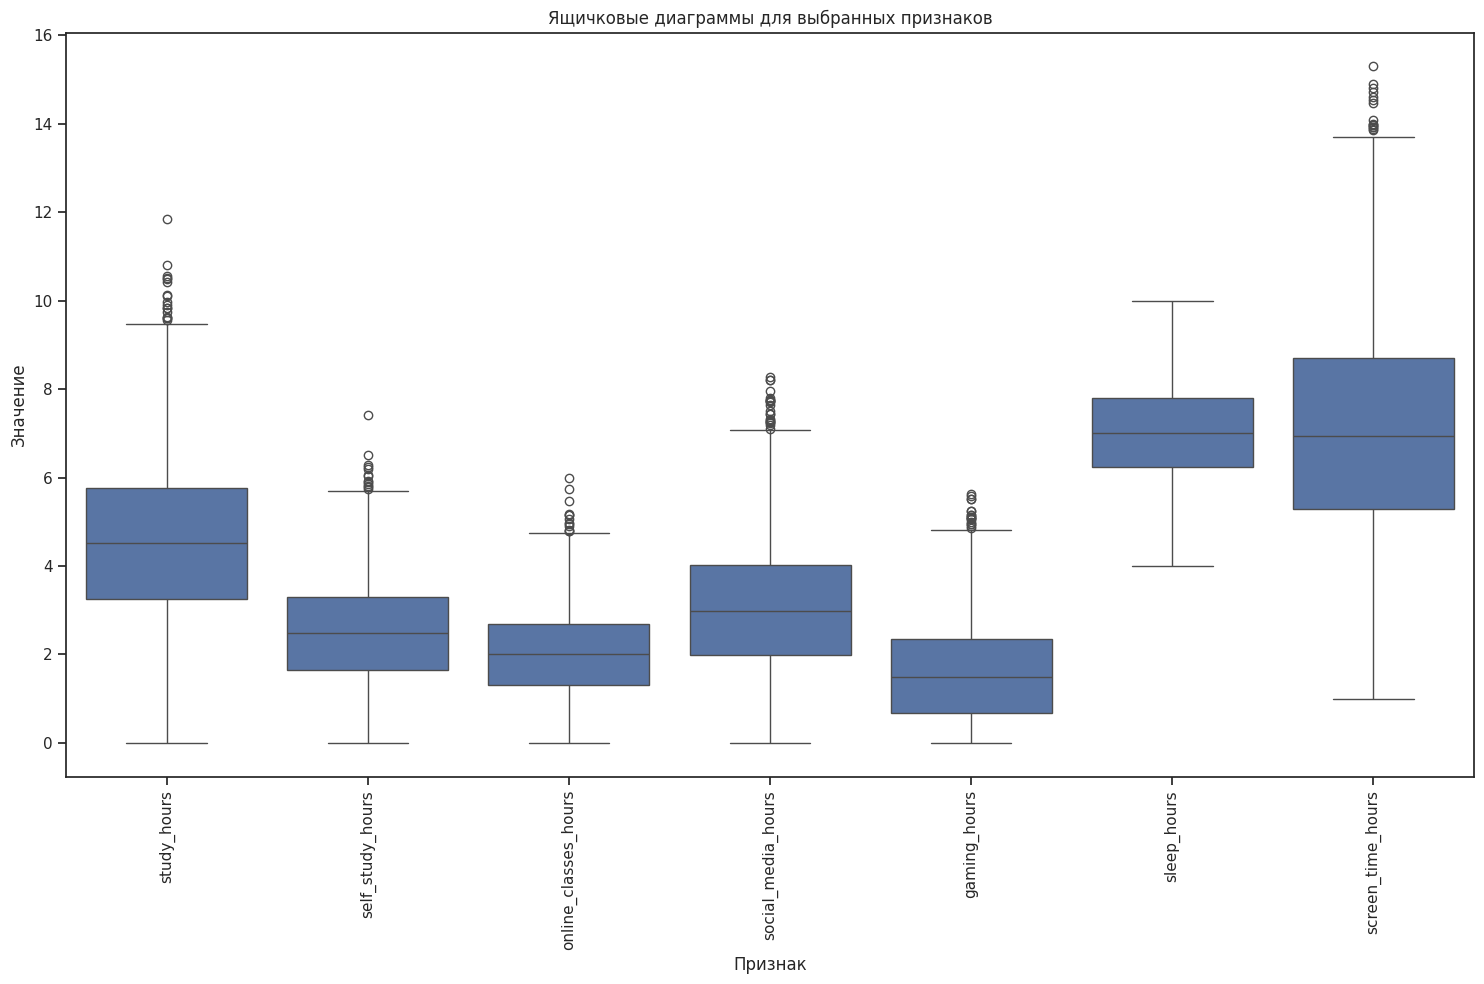

In [39]:
#Построим боксплоты, чтобы проанализоровать датасет на наличие выбросов
selected_features = ['study_hours', 'self_study_hours', 'online_classes_hours', 'social_media_hours', 'gaming_hours', 'sleep_hours', 'screen_time_hours']

plt.figure(figsize=(15, 10))
data_melted = data[selected_features].melt(var_name='Признак', value_name='Значение')
sns.boxplot(x='Признак', y='Значение', data=data_melted)
plt.xticks(rotation=90)
plt.title('Ящичковые диаграммы для выбранных признаков')
plt.xlabel('Признак')
plt.ylabel('Значение')
plt.tight_layout()
plt.show()

<p>Видим большое количество выбросов, что ещё раз подтверждает, что выбранный датасет не очень хорошего качества.</p>

<Figure size 1500x1200 with 0 Axes>

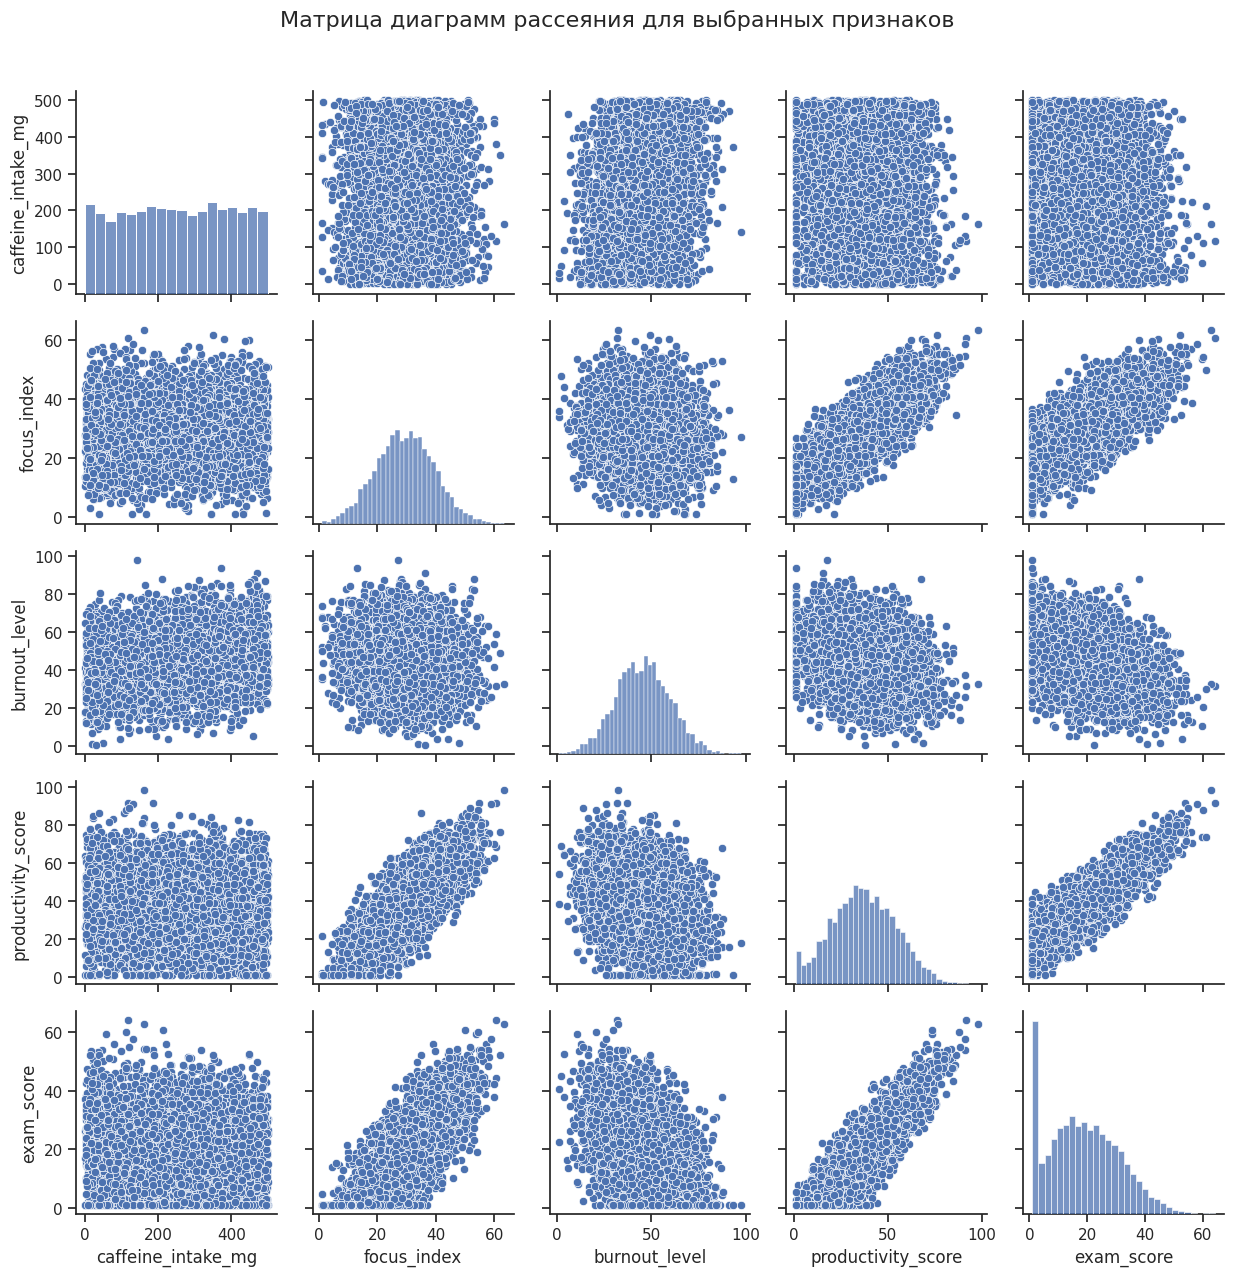

In [47]:
#Построим парные графики, чтобы найти взаимосвязь между каждой парой признаков и целевым признаком
selected_features = ['caffeine_intake_mg', 'focus_index', 'burnout_level', 'productivity_score', 'exam_score']

plt.figure(figsize=(15, 12))
sns.pairplot(data[selected_features], diag_kind='hist')
plt.suptitle('Матрица диаграмм рассеяния для выбранных признаков', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

<p>Видим, что в датасете мало линейных зависимостей между признаками, хотя и наблюдаются логичные связи, например, оценка продуктивности и баллы за экзамен.</p>

<h2>4) Информация о корреляции признаков</h2>

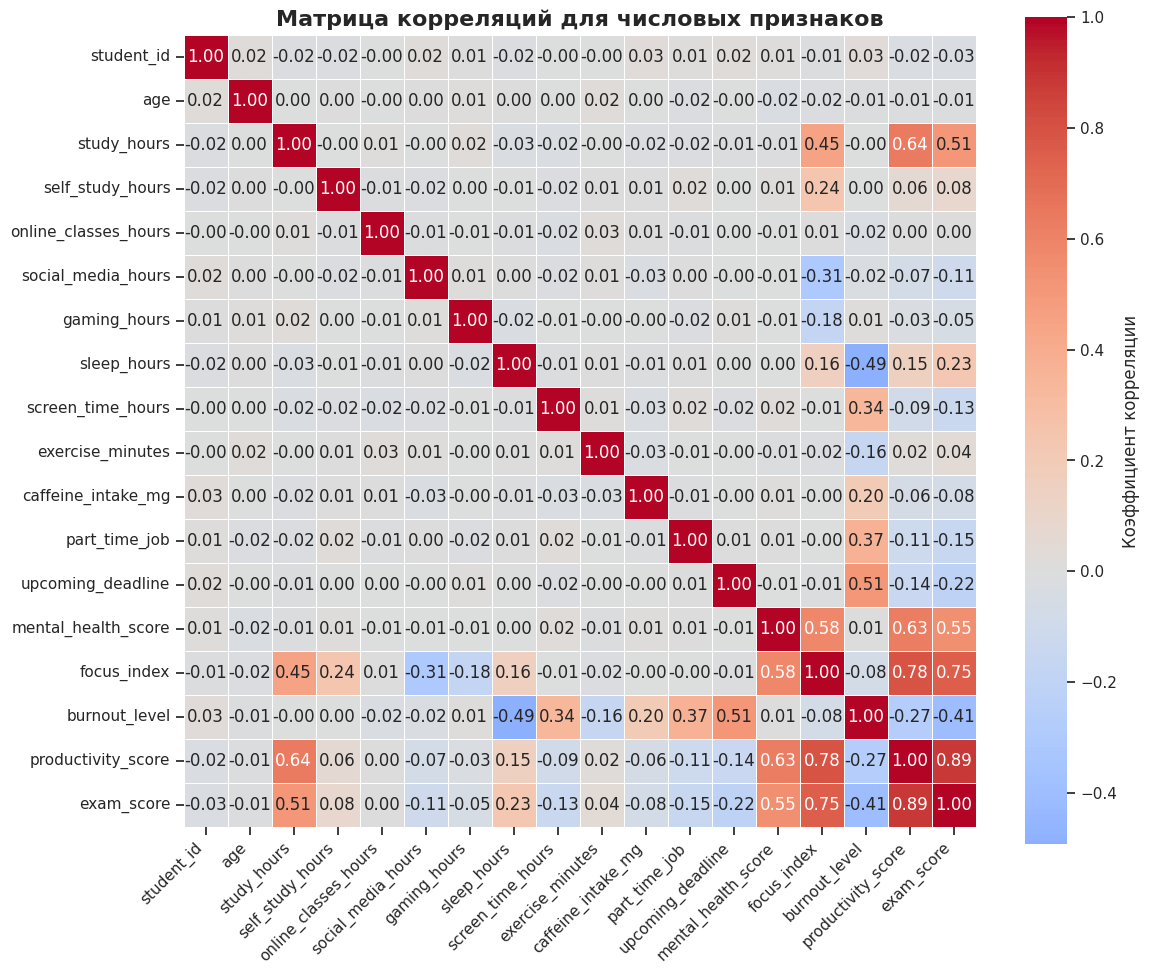

In [51]:
#Построим матрицу корреляций, для нахождения связи между различными парами признаков
numeric_cols = data.select_dtypes(include=['number']).columns.tolist()

plt.figure(figsize=(12, 10))
correlation_matrix = data[numeric_cols].corr()

sns.heatmap(correlation_matrix, 
            annot=True,           
            fmt='.2f',            
            cmap='coolwarm',      
            center=0,             
            square=True,          
            linewidths=0.5,       
            cbar_kws={'label': 'Коэффициент корреляции'})

plt.title('Матрица корреляций для числовых признаков', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<p>На этой матрице видно, что большинство признаков коррелирует только с уровнями сфокусированности, выгорания и продуктивности, что в очередной раз указывает на некачественность датасета.</p>